# Downstream analysis of inter-jump intervals.

### Analysis includes:
1. Generating a summary table of median inter-jump intervals for each mutation.
2. Statistical test for checking the importance.
3. Generating supportive plots.

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

In [19]:
PROJECT_ROOT = Path('..').resolve()
TASK_OUTPUT = PROJECT_ROOT / "outputs/"
INPUT_DATA = PROJECT_ROOT / "outputs" / "jumps.parquet"

In [4]:
df = pd.read_parquet(INPUT_DATA)
# We calculate the delta between each jumps for each unique cell in a specified site.
df['jump_delta'] = df.groupby(['Image_Metadata_Site', 'track_id'])['time_h'].diff()
# Delete NaN's - first occurance for a jump in a cell.
jumps = df.dropna(subset=['jump_delta'])

In [5]:
jumps.head()

,node_id,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,time_h,objNuclei_Location_Center_X,objNuclei_Location_Center_Y,Nuclear_size,ERKKTR_ratio,...,signal_delta,jump_event,neighbor_count,neighbor_jump_count,neighbor_jump_now,neighbor_mean_signal,future_self_jump,Site,Mutation,jump_delta
2,2,1,1,1,2,0.166667,932.376,873.787,314.000,1.059170,...,0.210928,True,22,5,True,1.004497,True,1,WT,0.083333
3,3,1,1,1,3,0.250000,932.168,873.453,322.000,1.188000,...,0.128830,True,22,8,True,1.029900,False,1,WT,0.083333
13,13,1,1,1,13,1.083333,931.003,871.117,309.000,0.886782,...,0.051232,True,21,2,True,0.899042,False,1,WT,0.833333
20,20,1,1,1,20,1.666667,929.783,869.184,309.000,0.736695,...,0.039816,True,19,1,True,0.833145,False,1,WT,0.583333
28,28,1,1,1,28,2.333333,929.243,867.353,337.001,0.682593,...,0.046156,True,19,1,True,0.799708,False,1,WT,0.666667


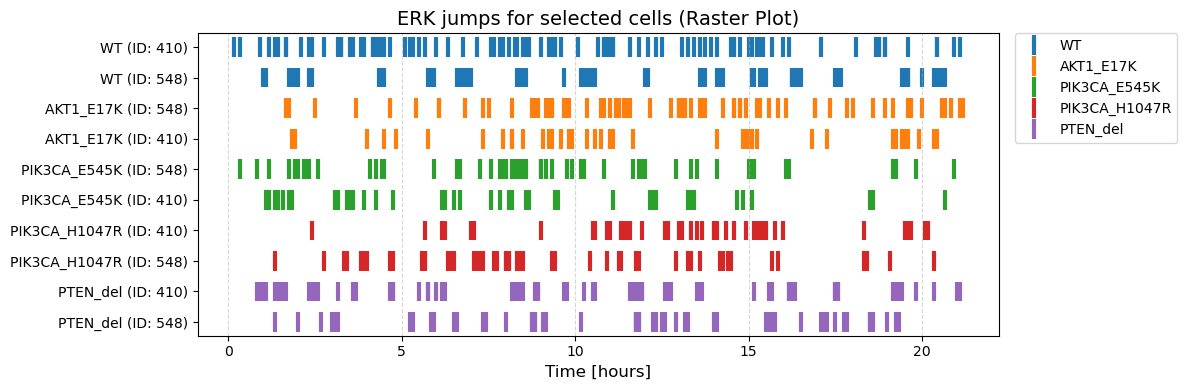

In [57]:
# Discrete raster plot for our cell "jumps" for chosen track id's.

top_tracks = jumps['track_id'].value_counts().head(2).index
example_jumps = jumps[jumps['track_id'].isin(top_tracks)].copy()

# Unique identifiers so that the same track id's don't get mixed up.
example_jumps['cell_label'] = example_jumps['Mutation'] + " (ID: " + example_jumps['track_id'].astype(str) + ")"

plt.figure(figsize=(12, 4))
sns.scatterplot(
    data=example_jumps, 
    x='time_h', 
    y='cell_label', 
    marker='|',
    s=200,        
    linewidth=3,
    hue='Mutation'
)

plt.title('ERK jumps for selected cells (Raster Plot)', fontsize=14)
plt.xlabel('Time [hours]', fontsize=12)
plt.ylabel('', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(TASK_OUTPUT / "ERK_jumps.png")
plt.show()

In [ ]:
# Aggregate the cells by each of the sites and unique cell id's, there can be the same track_ids for different sites.
cell_jumps = jumps.groupby(
    ['Image_Metadata_Site', 'track_id', 'Mutation']
)[['jump_delta', 'neighbor_jump_count']].median().reset_index()

# IJI - inter-jump interval
cell_jumps.rename(columns={'jump_delta': 'median_IJI'}, inplace=True)
# Normally the time is in hours, minutes seem more clear.
cell_jumps['median_IJI_min'] = cell_jumps['median_IJI'] * 60

In [11]:
cell_jumps[cell_jumps["track_id"]==1]

,Image_Metadata_Site,track_id,Mutation,median_IJI,neighbor_jump_count,median_IJI_min
0,1,1,WT,0.083333,4.0,5.0
2632,3,1,WT,0.083333,1.0,5.0
3998,4,1,WT,1.083333,2.0,65.0
5468,5,1,AKT1_E17K,0.666667,1.0,40.0
7128,6,1,AKT1_E17K,0.250000,1.0,15.0
8731,7,1,AKT1_E17K,2.291667,1.0,137.5
11789,9,1,PIK3CA_E545K,1.083333,1.0,65.0
13260,10,1,PIK3CA_E545K,1.583333,1.5,95.0
14843,11,1,PIK3CA_E545K,2.583333,1.0,155.0
16553,12,1,PIK3CA_E545K,1.291667,1.0,77.5


In [12]:
# Sanity check of our data.
print(cell_jumps.groupby('Mutation')['median_IJI_min'].describe())

                count       mean         std  min   25%   50%    75%     max
Mutation                                                                    
AKT1_E17K      6321.0  74.159943  124.630809  5.0  15.0  30.0   75.0  1270.0
PIK3CA_E545K   6301.0  83.343120  104.423751  5.0  22.5  55.0  100.0  1210.0
PIK3CA_H1047R  3253.0  69.734092   99.221245  5.0  15.0  37.5   85.0  1175.0
PTEN_del       3511.0  49.312162   75.932970  5.0   5.0  27.5   65.0  1245.0
WT             5468.0  29.370885   75.313592  5.0   5.0   5.0   22.5  1220.0


### Is there a significant difference in ERK signal oscillation between different mutants?

In [ ]:
mutants = ["WT", "AKT1_E17K", "PIK3CA_E545K", "PIK3CA_H1047R", "PTEN_del"]
wt_data = cell_jumps[cell_jumps["Mutation"]=="WT"]["median_IJI"]

# p value correction, same as in the first task.
alpha = 0.05
alpha_adj = alpha / len(mutants)
results = []

In [16]:
# Generate a summary table.
for mut in mutants:
    mut_samples = cell_jumps[cell_jumps["Mutation"] == mut]['median_IJI']
    u_stat, p_raw = stats.mannwhitneyu(wt_data, mut_samples, alternative='two-sided')
    results.append({
        'Mutation': mut,
        'p_raw': p_raw,
        'is_significant': p_raw < alpha_adj,
        'median_IJI': mut_samples.median(),
        'median_IJI_min': (mut_samples.median())*60
    })

In [20]:
results_df = pd.DataFrame(results)
results_df.to_csv(TASK_OUTPUT / "intervals_table.csv")

/tmp/ipykernel_13190/3081495828.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


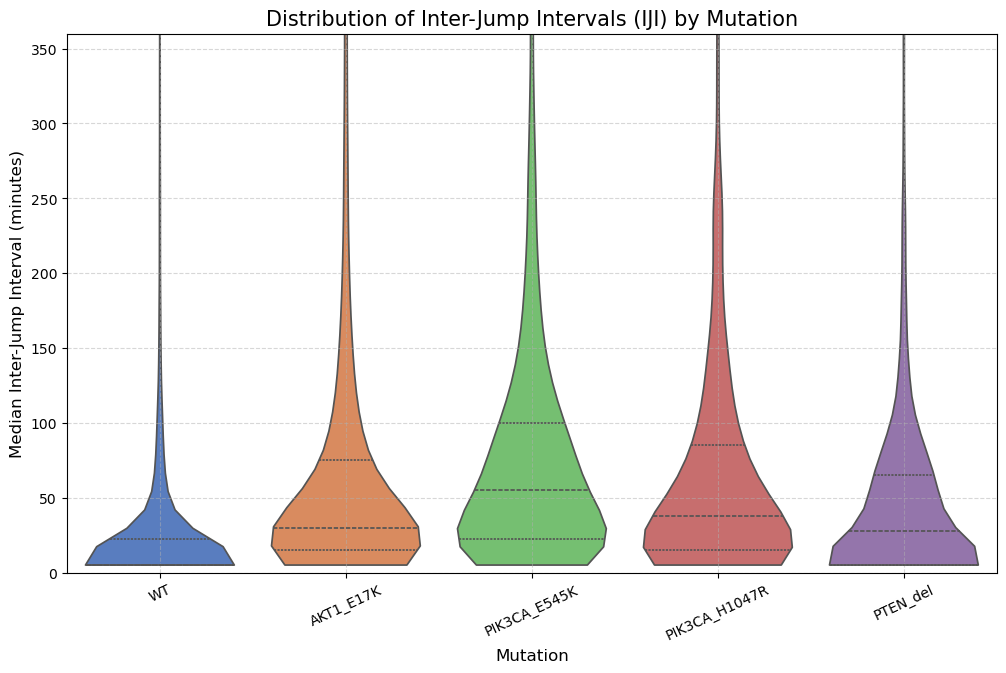

In [46]:
# Generate a violin plot showing distribution of IJI per mutation.

plt.figure(figsize=(12, 7))
ax = sns.violinplot(
    data=cell_jumps, 
    x='Mutation', 
    y='median_IJI_min', 
    palette='muted',
    inner='quartile',
    cut=0, 
)

plt.title('Distribution of Inter-Jump Intervals (IJI) by Mutation', fontsize=15)
plt.ylabel('Median Inter-Jump Interval (minutes)', fontsize=12)
plt.xlabel('Mutation', fontsize=12)
plt.xticks(rotation=25)
plt.grid(True, linestyle='--', alpha=0.5)

# Crop to 6 hour limit for better visualization.
plt.ylim(0, 360)
plt.savefig(TASK_OUTPUT / "jump_oscillation_violin.png")
plt.show()

### Does the jump oscillation of a cell depend on its neighbors jumping? (Local RR)

In [65]:
# Calculate Spearman correlation between median neighbour count and inter jump intervals.
results = []

for mut in mutants:
    mut_data = cell_jumps[cell_jumps['Mutation'] == mut]
    corr, p_value = stats.spearmanr(mut_data['median_IJI_min'], mut_data['neighbor_jump_count'])
    results.append({
        "Mutation": mut,
        "neigh_interval_corr": f"{corr:.3f}"   
    })

In [67]:
corr_df = pd.DataFrame(results)
corr_df.to_csv(TASK_OUTPUT / "iji_&_neigbours_correlation.csv")

In [68]:
corr_df

,Mutation,neigh_interval_corr
0,WT,-0.033
1,AKT1_E17K,-0.195
2,PIK3CA_E545K,0.027
3,PIK3CA_H1047R,0.019
4,PTEN_del,-0.057
